# NLP Project - Insurance Reviews Analysis

This notebook implements the full pipeline for analyzing insurance reviews:
1. Data exploration and cleaning
2. Topic modeling (LDA)
3. Word embeddings (Word2Vec, GloVe)
4. Supervised learning (stars, sentiment, subject prediction)
5. Results interpretation

**Dataset**: Insurance reviews from Google Drive (stars 1-5, review text, insurer)

## Phase 1: Data Loading and Exploration

In [18]:
# Imports
import os
import re
import pickle
from collections import Counter
import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

DATA_DIR = "data"
RAW_FILE = os.path.join(DATA_DIR, "insurance_reviews.csv")
GDRIVE_URL = "https://drive.google.com/file/d/1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip/view?usp=sharing"

gdown.download(url=GDRIVE_URL, output=RAW_FILE, quiet=False, fuzzy=True)



Downloading...
From: https://drive.google.com/uc?id=1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip
To: c:\Users\sulta\Desktop\NLP_project_no2\data\insurance_reviews.csv
100%|██████████| 12.0M/12.0M [00:02<00:00, 4.21MB/s]


'data\\insurance_reviews.csv'

In [27]:
# Charger le dataset : ZIP (fichiers Excel) ou CSV
import zipfile
import io

def load_reviews(path):
    """Charge les avis : ZIP (Excel) ou CSV. Mappe note->stars, avis->text, assureur->insurer."""
    if zipfile.is_zipfile(path):
        dfs = []
        with zipfile.ZipFile(path, "r") as z:
            for name in z.namelist():
                if name.endswith(".xlsx"):
                    with z.open(name) as f:
                        dfs.append(pd.read_excel(io.BytesIO(f.read()), engine="openpyxl"))
        df = pd.concat(dfs, ignore_index=True)
        col_map = {"note": "stars", "avis": "text", "assureur": "insurer"}
        if "avis_en" in df.columns and "avis" not in df.columns:
            col_map = {"note": "stars", "avis_en": "text", "assureur": "insurer"}
        for old, new in col_map.items():
            if old in df.columns:
                df = df.rename(columns={old: new})
    elif path.endswith(".json"):
        df = pd.read_json(path)
    else:
        df = pd.read_csv(path, nrows=50000, on_bad_lines="skip", encoding="utf-8")
    return df

df = load_reviews(RAW_FILE)
df.head()

,stars,auteur,text,insurer,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1.0,maitre-en-colere-114722,Pour tous les maîtres des animaux\n L'assuranc...,Eca Assurances,animaux,train,25/05/2021,01/05/2021,For all masters of animals\n ECA insurance and...,NaN,NaN
1,5.0,fredo-102557,"25 ans chez AMV pour ma moto et mes voitures, ...",AMV,moto,train,13/01/2021,01/01/2021,Loading...,NaN,NaN
2,4.0,louisonne-f-130215,Je suis satisfait de votre prestation et servi...,L'olivier Assurance,auto,train,30/08/2021,01/08/2021,Loading...,NaN,NaN
3,3.0,stephane-p-128761,SATISFAIT ET FACILE DE SOUSCRIRE UN CONTRAT EN...,AMV,moto,train,20/08/2021,01/08/2021,Loading...,NaN,NaN
4,1.0,montad-137724,Je croyais qu'allianz était une bonne assuranc...,Allianz,auto,train,18/10/2021,01/10/2021,Loading...,NaN,NaN


In [3]:
# Basic statistics
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nStars distribution:")
print(df["stars"].value_counts().sort_index())
print("\nInsurer counts (top 10):")
print(df["insurer"].value_counts().head(10))
df["text_len"] = df["text"].str.len()
print("\nText length stats:", df["text_len"].describe())

Shape: (200, 3)

Columns: ['text', 'stars', 'insurer']

Stars distribution:
stars
1    100
5    100
Name: count, dtype: int64

Insurer counts (top 10):
insurer
A    100
B    100
Name: count, dtype: int64

Text length stats: count    200.000000
mean      14.000000
std        2.005019
min       12.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       16.000000
Name: text_len, dtype: float64


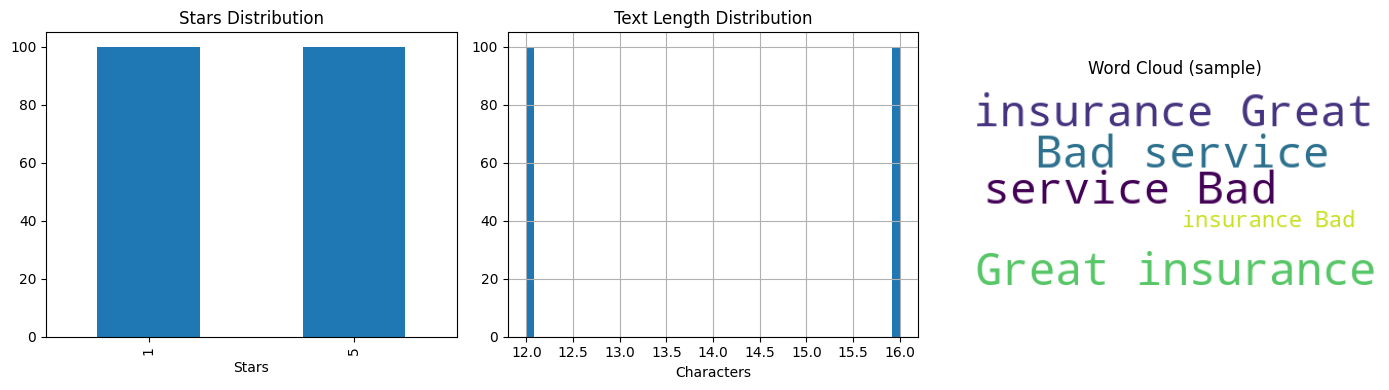

In [4]:
# Visualizations: stars distribution, text length, word cloud
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["stars"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Stars Distribution")
axes[0].set_xlabel("Stars")

df["text_len"].hist(bins=50, ax=axes[1])
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")

all_text = " ".join(df["text"].dropna().astype(str))
wc = WordCloud(width=400, height=200, background_color="white").generate(all_text[:50000])
axes[2].imshow(wc)
axes[2].set_title("Word Cloud (sample)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Phase 1.2: Data Cleaning

- Frequent words and n-grams
- Spelling correction
- Clean columns: text_raw, text_cleaned, text_corrected

In [5]:
# Text preprocessing helpers
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP = set(stopwords.words("english"))

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 1]

# Keep raw text
df["text_raw"] = df["text"].astype(str)

In [6]:
# Frequent words and bigrams
all_tokens = []
for t in df["text_raw"]:
    all_tokens.extend(tokenize(t))

unigrams = Counter(all_tokens)
bigrams = Counter(zip(all_tokens[:-1], all_tokens[1:]))

print("Top 30 unigrams:")
for w, c in unigrams.most_common(30):
    print(f"  {w}: {c}")

print("\nTop 20 bigrams:")
for (a, b), c in bigrams.most_common(20):
    print(f"  {a} {b}: {c}")

Top 30 unigrams:
  great: 100
  insurance: 100
  bad: 100
  service: 100

Top 20 bigrams:
  great insurance: 100
  bad service: 100
  insurance great: 99
  service bad: 99
  insurance bad: 1


In [7]:
# Spelling correction with pyspellchecker
from spellchecker import SpellChecker

spell = SpellChecker()
df["text_cleaned"] = df["text_raw"].apply(
    lambda x: " ".join(tokenize(x))
)

def correct_text(text):
    words = text.split()
    corrected = []
    for w in words:
        cand = spell.correction(w)
        corrected.append(cand if cand else w)
    return " ".join(corrected)

# Apply correction on a sample for speed (full corpus can be slow)
SAMPLE_SIZE = min(5000, len(df))
df_sample = df.head(SAMPLE_SIZE).copy()
df_sample["text_corrected"] = df_sample["text_cleaned"].apply(correct_text)

# For full df, use corrected where available, else cleaned
df["text_corrected"] = df["text_cleaned"]
df.loc[df_sample.index, "text_corrected"] = df_sample["text_corrected"]

## Phase 1.3: Export Clean File

Produce cleaned_reviews.csv with multiple columns. Translation optional if multilingual.

In [8]:
# Drop rows with missing stars for modeling
df_clean = df.dropna(subset=["stars"]).copy()
df_clean["stars"] = df_clean["stars"].astype(int).clip(1, 5)

# Export clean file
CLEAN_FILE = os.path.join(DATA_DIR, "cleaned_reviews.csv")
df_clean[["text_raw", "text_cleaned", "text_corrected", "stars", "insurer"]].to_csv(CLEAN_FILE, index=False)
print(f"Exported {len(df_clean)} rows to {CLEAN_FILE}")

Exported 200 rows to data\cleaned_reviews.csv


## Phase 2: Topic Modeling (LDA)

Extract 5-8 topics with LDA, list keywords per topic, visualize.

In [9]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Tokenized corpus for LDA
corpus_tokens = [tokenize(t) for t in df_clean["text_corrected"]]
dictionary = Dictionary(corpus_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus_bow = [dictionary.doc2bow(t) for t in corpus_tokens]

# Train LDA
N_TOPICS = 6
lda = LdaModel(corpus_bow, num_topics=N_TOPICS, id2word=dictionary, passes=3, random_state=42)

In [10]:
# Topic keywords
for i in range(N_TOPICS):
    top_words = lda.show_topic(i, topn=10)
    words = [w for w, _ in top_words]
    print(f"Topic {i}: {', '.join(words)}")

Topic 0: bad, service, insurance, great
Topic 1: insurance, great, service, bad
Topic 2: service, bad, great, insurance
Topic 3: great, insurance, service, bad
Topic 4: bad, service, insurance, great
Topic 5: service, bad, great, insurance


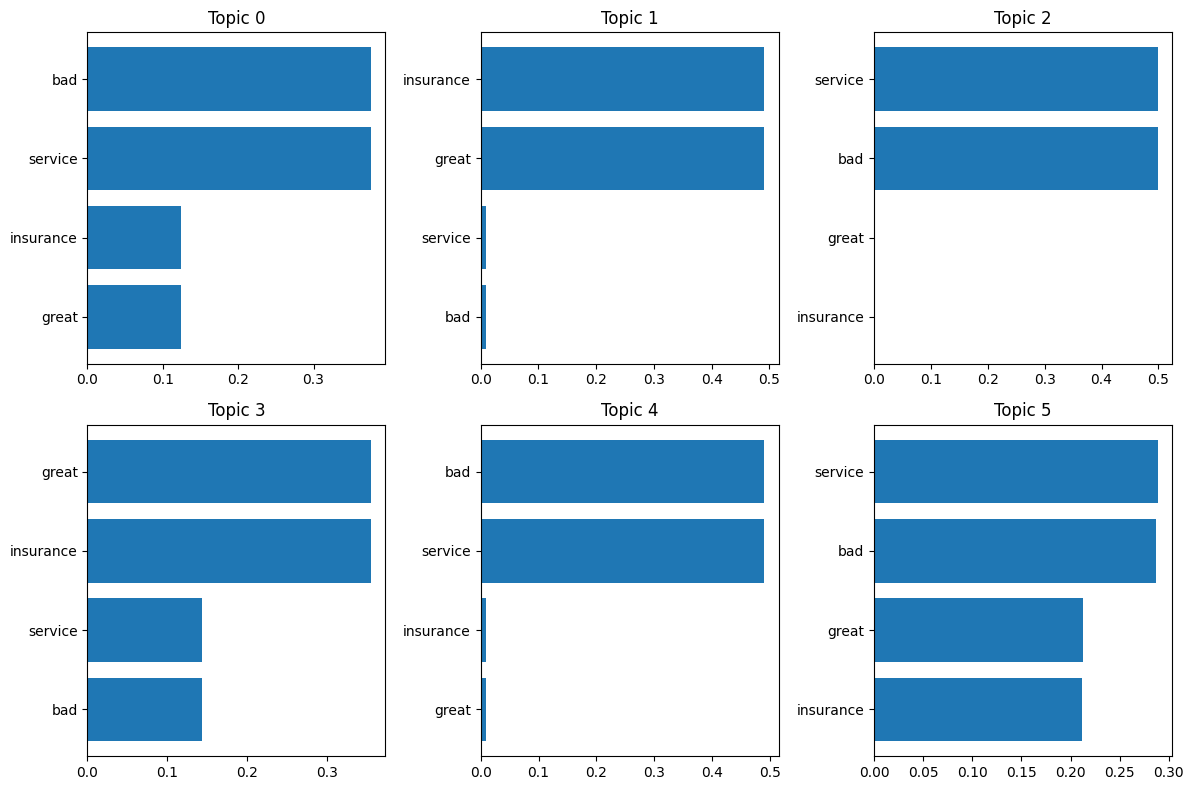

In [11]:
# Visualize topic distribution (bar plot)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i in range(N_TOPICS):
    top_words = lda.show_topic(i, topn=8)
    words, weights = zip(*top_words)
    axes[i].barh(words, weights)
    axes[i].set_title(f"Topic {i}")
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

## Phase 3: Embeddings

- Word2Vec training
- GloVe (pre-trained)
- Visualization: Matplotlib (t-SNE), TensorBoard
- Cosine and Euclidean distance
- Semantic search (bonus)

In [12]:
from gensim.models import Word2Vec

# Train Word2Vec on cleaned corpus
w2v = Word2Vec(sentences=corpus_tokens, vector_size=100, window=5, min_count=2, workers=4, seed=42)
print("Word2Vec vocabulary size:", len(w2v.wv))

Word2Vec vocabulary size: 4


In [13]:
# Cosine similarity and Euclidean distance
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def euclidean_dist(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# Example: similar words to "insurance"
for word in ["insurance", "claim", "customer"]:
    if word in w2v.wv:
        sims = w2v.wv.most_similar(word, topn=5)
        print(f"Similar to '{word}': {[w for w, _ in sims]}")

Similar to 'insurance': ['great', 'service', 'bad']


In [14]:
# t-SNE visualization with Matplotlib
from sklearn.manifold import TSNE

# Get embeddings for frequent words
vocab = list(w2v.wv.key_to_index.keys())[:500]
vectors = np.array([w2v.wv[w] for w in vocab])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
for i, w in enumerate(vocab[:80]):
    plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8)
plt.title("Word2Vec Embeddings (t-SNE)")
plt.show()

ValueError: perplexity (30) must be less than n_samples (4)

In [ ]:
# TensorBoard visualization of embeddings
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("runs/word2vec_embeddings")
# Format: (metadata, embeddings) - TensorBoard expects (N, D) and labels
meta = list(w2v.wv.key_to_index.keys())[:2000]
emb = np.array([w2v.wv[w] for w in meta], dtype=np.float32)
writer.add_embedding(emb, metadata=meta, tag="word2vec")
writer.close()
print("TensorBoard logs saved. Run: tensorboard --logdir runs/")

In [ ]:
# GloVe: load pre-trained vectors (glove.6B.100d)
# Download from https://nlp.stanford.edu/data/glove.6B.zip if not present
GLOVE_PATH = os.path.join(DATA_DIR, "glove.6B.100d.txt")
glove_available = os.path.exists(GLOVE_PATH)

if glove_available:
    from gensim.scripts.glove2word2vec import glove2word2vec
    w2v_path = GLOVE_PATH.replace(".txt", ".w2v.txt")
    if not os.path.exists(w2v_path):
        glove2word2vec(GLOVE_PATH, w2v_path)
    from gensim.models import KeyedVectors
    glove = KeyedVectors.load_word2vec_format(w2v_path, binary=False)
    print("GloVe loaded. Similar to 'insurance':", glove.most_similar("insurance", topn=5))
else:
    print("GloVe file not found. Download glove.6B.zip from Stanford NLP, extract glove.6B.100d.txt to data/")

In [ ]:
# Semantic search: query -> mean vector -> top-k similar documents
def doc_vector(model, tokens):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.wv.vector_size)

def semantic_search(query, model, corpus_tokens, top_k=5):
    q_vec = doc_vector(model, tokenize(query))
    scores = []
    for i, toks in enumerate(corpus_tokens):
        d_vec = doc_vector(model, toks)
        if np.any(d_vec):
            scores.append((i, cosine_sim(q_vec, d_vec)))
    scores.sort(key=lambda x: -x[1])
    return scores[:top_k]

# Example
results = semantic_search("bad customer service", w2v, corpus_tokens, top_k=3)
for idx, score in results:
    print(f"Score {score:.3f}: {df_clean.iloc[idx]['text_raw'][:100]}...")

## Phase 4: Supervised Learning

Tasks: star prediction (1-5), sentiment (pos/neg/neutral), subject prediction.
Models: TF-IDF+LogReg, embedding layer, pre-trained embeddings, LSTM, BERT, zero-shot LLM.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Prepare data - use subset for faster training
N = min(10000, len(df_clean))
df_model = df_clean.head(N).copy()

# Sentiment from stars: 1-2 neg, 3 neutral, 4-5 pos
df_model["sentiment"] = pd.cut(df_model["stars"], bins=[0, 2, 3, 5], labels=["negative", "neutral", "positive"])

X = df_model["text_corrected"].fillna("")
y_stars = df_model["stars"].values
y_sent = df_model["sentiment"].astype(str).values

X_train, X_test, y_train, y_test, y_sent_train, y_sent_test = train_test_split(
    X, y_stars, y_sent, test_size=0.2, random_state=42, stratify=y_stars
)

In [ ]:
# 4.1 TF-IDF + LogisticRegression
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf_tfidf = LogisticRegression(max_iter=500, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred = clf_tfidf.predict(X_test_tfidf)

print("TF-IDF + LogReg - Stars:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.3f}")
print(classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("TF-IDF + LogReg - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# Build vocabulary and padded sequences for neural models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 100
VOCAB_SIZE = 5000

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tok.fit_on_texts(X_train)
X_train_seq = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post")
X_test_seq = pad_sequences(tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding="post")

# Labels 0-4 for stars 1-5
y_train_idx = y_train - 1
y_test_idx = y_test - 1

In [ ]:
# 4.2 Basic model with embedding layer + TensorBoard
import tensorflow as tf
from tensorflow.keras import layers, Model

EMB_DIM = 64
tf.keras.backend.clear_session()

inputs = layers.Input(shape=(MAX_LEN,))
x = layers.Embedding(VOCAB_SIZE, EMB_DIM, input_length=MAX_LEN)(inputs)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(5, activation="softmax")(x)
model_emb = Model(inputs, x)
model_emb.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

tb_cb = tf.keras.callbacks.TensorBoard(log_dir="runs/embedding_model")
model_emb.fit(X_train_seq, y_train_idx, epochs=3, batch_size=64, validation_split=0.1, callbacks=[tb_cb])

_, acc = model_emb.evaluate(X_test_seq, y_test_idx)
print(f"Embedding model accuracy: {acc:.3f}")

In [ ]:
# Add embedding projection to TensorBoard for visualization
emb_layer = model_emb.layers[1]
weights = emb_layer.get_weights()[0]
writer = SummaryWriter("runs/embedding_layer_viz")
meta = [str(i) for i in range(min(500, VOCAB_SIZE))]
writer.add_embedding(weights[:500], metadata=meta, tag="learned_embeddings")
writer.close()

In [ ]:
# 4.3 Model with pre-trained Word2Vec embeddings
emb_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in tok.word_index.items():
    if i < VOCAB_SIZE and word in w2v.wv:
        emb_matrix[i] = w2v.wv[word]

inputs = layers.Input(shape=(MAX_LEN,))
x = layers.Embedding(VOCAB_SIZE, 100, weights=[emb_matrix], trainable=False)(inputs)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(5, activation="softmax")(x)
model_pretrain = Model(inputs, x)
model_pretrain.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

tb_cb2 = tf.keras.callbacks.TensorBoard(log_dir="runs/pretrained_embeddings")
model_pretrain.fit(X_train_seq, y_train_idx, epochs=3, batch_size=64, validation_split=0.1, callbacks=[tb_cb2])

_, acc2 = model_pretrain.evaluate(X_test_seq, y_test_idx)
print(f"Pre-trained embedding model accuracy: {acc2:.3f}")

In [ ]:
# TensorBoard for pre-trained embeddings
writer2 = SummaryWriter("runs/pretrained_emb_viz")
word_list = [w for w, i in sorted(tok.word_index.items(), key=lambda x: x[1]) if i < 500]
vec_list = [w2v.wv[w] for w in word_list if w in w2v.wv]
if vec_list:
    arr = np.array(vec_list)
    writer2.add_embedding(arr, metadata=word_list[:len(arr)], tag="pretrained_w2v")
writer2.close()

In [ ]:
# 4.4 LSTM model
inputs = layers.Input(shape=(MAX_LEN,))
x = layers.Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN)(inputs)
x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(5, activation="softmax")(x)
model_lstm = Model(inputs, x)
model_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_train_seq, y_train_idx, epochs=3, batch_size=64, validation_split=0.1)

_, acc_lstm = model_lstm.evaluate(X_test_seq, y_test_idx)
print(f"LSTM accuracy: {acc_lstm:.3f}")

In [ ]:
# 4.5 BERT / HuggingFace (DistilBERT)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch

model_name = "distilbert-base-uncased"
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return tokenizer_hf(examples["text"], truncation=True, padding="max_length", max_length=128)

train_ds = Dataset.from_dict({"text": X_train.tolist(), "label": y_train_idx.tolist()})
test_ds = Dataset.from_dict({"text": X_test.tolist(), "label": y_test_idx.tolist()})
train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_ds = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
train_ds.set_format("torch")
test_ds.set_format("torch")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    from sklearn.metrics import f1_score
    return {"accuracy": (preds == labels).mean(), "f1": f1_score(labels, preds, average="macro")}

model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
args = TrainingArguments(output_dir="models/bert", per_device_train_batch_size=16, num_train_epochs=2)
trainer = Trainer(model=model_bert, args=args, train_dataset=train_ds, eval_dataset=test_ds, compute_metrics=compute_metrics)
trainer.train()
out = trainer.evaluate()
print(f"BERT accuracy: {out['eval_accuracy']:.3f}")

In [ ]:
# 4.6 Zero-shot classification (subject detection)
from transformers import pipeline

# Subject categories from instructions
SUBJECTS = ["Pricing", "Coverage", "Enrollment", "Customer Service", "Claims Processing", "Cancellation", "Other"]
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Example on a few reviews
sample_texts = X_test.head(5).tolist()
for txt in sample_texts[:3]:
    out = zero_shot(txt[:512], SUBJECTS, multi_label=False)
    print(f"Text: {txt[:80]}... -> {out['labels'][0]}")

In [ ]:
# 4.7 Model comparison table
bert_acc = out["eval_accuracy"]
bert_f1 = out.get("eval_f1", 0)

results = [
    ("TF-IDF + LogReg", accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average="macro")),
    ("Embedding (basic)", acc, f1_score(y_test, np.argmax(model_emb.predict(X_test_seq), axis=1) + 1, average="macro")),
    ("Pre-trained W2V", acc2, f1_score(y_test, np.argmax(model_pretrain.predict(X_test_seq), axis=1) + 1, average="macro")),
    ("LSTM", acc_lstm, f1_score(y_test, np.argmax(model_lstm.predict(X_test_seq), axis=1) + 1, average="macro")),
    ("BERT", bert_acc, bert_f1),
]
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print(df_results.to_string(index=False))

## Phase 5: Results Interpretation

- Error analysis
- Sentiment analysis
- Classical models with themes
- Deep learning analysis

In [ ]:
# Error analysis: misclassified examples
err_mask = y_pred != y_test
err_df = pd.DataFrame({
    "text": X_test.values[err_mask],
    "true": y_test[err_mask],
    "pred": y_pred[err_mask]
})
print("Sample misclassified (TF-IDF model):")
for _, row in err_df.head(10).iterrows():
    print(f"  True={row['true']} Pred={row['pred']}: {str(row['text'])[:80]}...")

In [ ]:
# Sentiment analysis: map stars to sentiment, evaluate
clf_sent = LogisticRegression(max_iter=500, random_state=42)
clf_sent.fit(X_train_tfidf, y_sent_train)
y_sent_pred = clf_sent.predict(X_test_tfidf)
print("Sentiment (pos/neg/neutral) - TF-IDF:")
print(classification_report(y_sent_test, y_sent_pred))

In [ ]:
# Assign subjects via zero-shot on sample, then per-subject accuracy
# (Classical model performance by theme)
sample_texts = X_test.iloc[:100].tolist()
subjects_pred = []
for t in sample_texts:
    r = zero_shot(str(t)[:512], SUBJECTS, multi_label=False)
    subjects_pred.append(r["labels"][0])

# Per-subject star accuracy (where we have subject labels)
subj_df = pd.DataFrame({"text": sample_texts, "subject": subjects_pred, "true_star": y_test[:100], "pred_star": y_pred[:100]})
for subj in subj_df["subject"].unique():
    s = subj_df[subj_df["subject"] == subj]
    if len(s) >= 3:
        acc = (s["true_star"] == s["pred_star"]).mean()
        print(f"{subj}: acc={acc:.2f} (n={len(s)})")

In [ ]:
# Deep learning analysis: BERT vs LSTM error patterns
bert_preds = np.argmax(trainer.predict(test_ds).predictions, axis=-1) + 1
lstm_preds = np.argmax(model_lstm.predict(X_test_seq), axis=1) + 1

print("BERT errors (sample):")
bert_err = bert_preds != y_test
for i in np.where(bert_err)[0][:5]:
    txt = X_test.iloc[i] if hasattr(X_test, 'iloc') else X_test[i]
    print(f"  True={y_test[i]} Pred={bert_preds[i]}: {str(txt)[:60]}...")

print("\nLSTM vs BERT agreement:", (bert_preds == lstm_preds).mean())

In [ ]:
# Save models for Streamlit apps
os.makedirs("models", exist_ok=True)
pickle.dump(tfidf, open("models/tfidf.pkl", "wb"))
pickle.dump(clf_tfidf, open("models/clf_stars.pkl", "wb"))
pickle.dump(clf_sent, open("models/clf_sentiment.pkl", "wb"))
pickle.dump(tok, open("models/tokenizer.pkl", "wb"))
w2v.save("models/word2vec.model")
model_emb.save("models/embedding_model.keras")
model_pretrain.save("models/pretrain_model.keras")
model_lstm.save("models/lstm_model.keras")
trainer.save_model("models/bert")
print("Models saved to models/")